In [31]:
# All necessary imports
import numpy as np
import matplotlib.pyplot as plt

# This command ensures plots are displayed directly in the notebook
%matplotlib inline


In [38]:
def process_and_plot_sequence(sequence_steps, channel_mapping, total_period_us=None):
    """
    Processes a user-defined sequence, plots it, and returns the low-level data.

    Args:
        sequence_steps (list): A list of dictionaries defining the pulse sequence.
        channel_mapping (dict): A map of channel names to physical channel numbers.
        total_period_us (float, optional): The total period of the sequence in µs.
                                           If None, the period is the sum of all step durations.
                                           Defaults to None.

    Returns:
        list: The low-level sequence_data list of (duration_ns, [HIGH_channels], ...) tuples.
    """
    print("--- Processing Sequence ---")
    
    # --- 1. Process and Validate the Sequence ---
    full_sequence = sequence_steps
    
    # If a fixed period is given, calculate and add the wait time.
    if total_period_us is not None:
        defined_duration_us = sum(step['duration_us'] for step in sequence_steps)
        print(f"Total defined duration: {defined_duration_us:.2f} µs")
        wait_time_us = total_period_us - defined_duration_us
        if wait_time_us < 0:
            raise ValueError(f"The sum of pulse durations ({defined_duration_us} µs) exceeds the fixed total period ({total_period_us} µs)!")
        print(f"Calculated wait time: {wait_time_us:.2f} µs")
        full_sequence = sequence_steps + [{'duration_us': wait_time_us, 'channels_on': []}]
    # If no period is given, calculate it from the sum of steps.
    else:
        total_period_us = sum(step['duration_us'] for step in sequence_steps)
        print(f"Total period automatically set to sum of pulses: {total_period_us:.2f} µs")

    # Convert to the low-level format for hardware
    low_level_sequence = []
    for step in full_sequence:
        duration_ns = int(step['duration_us'] * 1000)
        high_channels = [channel_mapping.get(name) for name in step['channels_on']]
        if duration_ns > 0:
            low_level_sequence.append((duration_ns, high_channels, 0.0, 0.0))
    
    print(f"Final sequence duration: {sum(d for d,_,_,_ in low_level_sequence) / 1000:.2f} µs\n")

    # --- 2. Plot the Sequence ---
    print("--- Generating Plot ---")
    fig, ax = plt.subplots(figsize=(12, 6))
    channel_names = {v: k for k, v in channel_mapping.items()}

    for chan_num in range(1, 9): # Plot all 8 channels
        x_coords, y_coords = [0], [0]
        current_time_ns = 0
        for duration_ns, high_channels, _, _ in low_level_sequence:
            level = 1 if chan_num in high_channels else 0
            if y_coords[-1] != level:
                x_coords.append(current_time_ns)
                y_coords.append(level)
            current_time_ns += duration_ns
            x_coords.append(current_time_ns)
            y_coords.append(level)
        
        time_us = np.array(x_coords) / 1000.0
        waveform = np.array(y_coords) * 0.8 + (chan_num - 1)
        ax.plot(time_us, waveform, label=channel_names.get(chan_num))

    ax.set_title('Pulse Sequence Verification', fontsize=16)
    ax.set_xlabel('Time ($\mu s$)', fontsize=12)
    ax.set_ylabel('Digital Channel', fontsize=12)
    ax.set_yticks(range(8))
    ax.set_yticklabels([f'CH {i+1}' for i in range(8)])
    ax.set_ylim(-0.5, 8)
    ax.set_xlim(0, total_period_us)
    ax.grid(axis='y', linestyle=':')
    if any(channel_names.values()):
        ax.legend()
    plt.show()
    
    return low_level_sequence, total_period_us



In [39]:
# --- 1.1 Channel Configuration ---
# Map human-readable names to the physical, 1-indexed channel numbers (1-8).
# This makes the sequence definition below much more intuitive.
channel_map = {
    'Laser': 1,
    'Repump': 2,
    'Trigger': 5,
    'Pulse_CH7': 7
}

# --- 1.2 Global Timing Configuration ---
# The total period for one repetition of the sequence in microseconds (µs).
TOTAL_PERIOD_US = None

In [ ]:
# Define the sequence of events. Use the names you defined in the channel_map.
pulse_sequence_steps = [
    {
        'duration_us': 0.05,  # 50 ns
        'channels_on': ['Trigger']
    },
    {
        'duration_us': 200, # Remainder of the first laser pulse
        'channels_on': ['Laser']
    },
    {
        'duration_us': 200,
        'channels_on': ['Pulse_CH7']
    },
     {
        'duration_us': 200,
        'channels_on': ['Laser']
    },
    {
        'duration_us': 50,
        'channels_on': ['Laser']
    },
    {
        'duration_us': 10,    # Repump pulse (set to 0 for now)
        'channels_on': ['Repump']
    }
    # The final wait time with all channels OFF is calculated automatically.
]

--- Processing Sequence ---
Total period automatically set to sum of pulses: 460.00 µs
Final sequence duration: 460.00 µs

--- Generating Plot ---


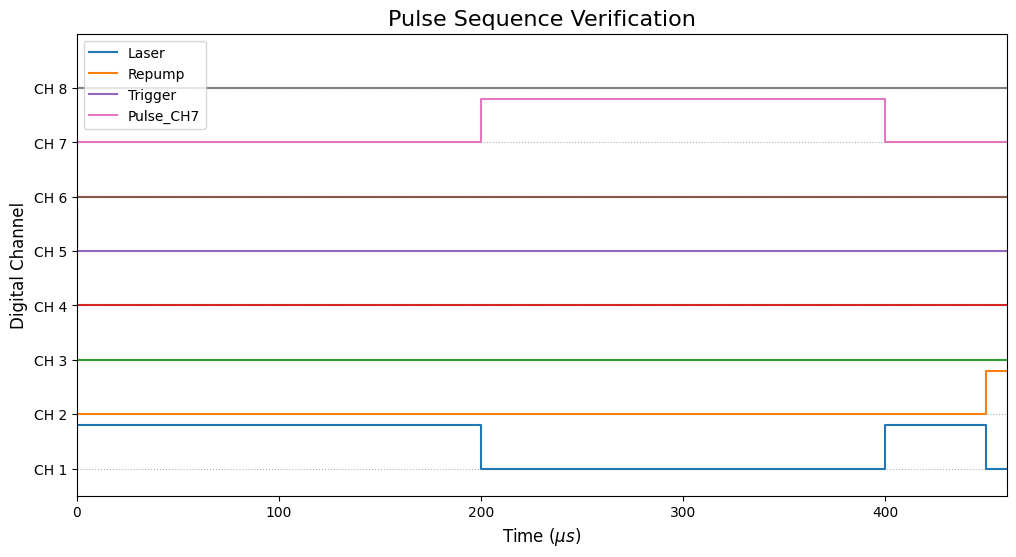

In [41]:
# --- Run the function with our defined parameters ---
final_sequence_data, TOTAL_PERIOD_US = process_and_plot_sequence(
    sequence_steps=pulse_sequence_steps,
    channel_mapping=channel_map,
    total_period_us=None # This is None, so period will be auto-calculated
)

In [30]:
print("Uploading sequence with trigger and repump to the Pulse Streamer...")

pulsestreamer.upload_sequence(final_sequence_data)

print("Starting the pulse sequence...")

pulsestreamer.start_streaming(n_runs=-1)


Uploading sequence with trigger and repump to the Pulse Streamer...
Starting the pulse sequence...


In [12]:
TOTAL_PERIOD_US

550.0

In [23]:
# --- Channel Configuration ---
# Map human-readable names to the physical, 1-indexed channel numbers (1-8).
# I've assigned 'Readout' and 'Initialization' to channels, you can change these.
channel_map = {
    'Readout': 1,
    'Initialization': 2,
}

# --- Global Timing Configuration ---
# We set this to None so the total period is determined by the sum of the pulses you define.
TOTAL_PERIOD_US = None

In [24]:
# --- Define the variable wait time in microseconds (µs) ---
VARIABLE_WAIT_US = 500  # <--- CHANGE THIS VALUE

# Define the sequence of events using the variable.
pulse_sequence_steps = [
    {
        'duration_us': 50,
        'channels_on': ['Readout']
    },
    {
        'duration_us': 200,
        'channels_on': []  # Waiting time, all channels off
    },
    {
        'duration_us': 200,
        'channels_on': ['Initialization']
    },
    {
        'duration_us': VARIABLE_WAIT_US,
        'channels_on': []  # This is the variable delay
    }
]